In [12]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from aedat_dataset import AEDATRespirationDataset
from models.dvRespNet import EventRespirationNet
import numpy as np
import dv_processing as dv
import tonic
import tonic.transforms as TT
import time
from datetime import timedelta

In [13]:
DATA_DIR = "../data/042025"
CSV_PATH = "../data/ground_truth.csv"
CHECKPOINT_PATH = "cpks/best_model-epoch=79-val_loss=0.42.ckpt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 1

In [14]:
capture = dv.io.CameraCapture()

filter_chain = dv.EventFilterChain()
filter_chain.addFilter(dv.noise.BackgroundActivityNoiseFilter(capture.getEventResolution(), backgroundActivityDuration=timedelta(milliseconds=1)))

In [15]:
dvEvents = []
dvEventStores = []

def process_events(eventstore, starttime):
        dtype = [('p', '<i4'),  ('t', '<i4'), ('x', '<i4'), ('y', '<i4')]
        
        if eventstore is None:
            return None
        
        # Capture the start time of the events
        
        # Pre-allocate a NumPy array for efficiency
        events = np.empty(len(eventstore), dtype=dtype)
        
        # Pre-allocate arrays for each attribute
        polarity = np.empty(len(eventstore), dtype=np.int32)
        x = np.empty(len(eventstore), dtype=np.int32)
        y = np.empty(len(eventstore), dtype=np.int32)
        timestamp = np.empty(len(eventstore), dtype=np.float64)
        
        #print("processtime 1: " + str(time.time() - processstart))
        
        # Fill the arrays using a for-loop, avoiding the overhead of zip
        for i, ev in enumerate(eventstore):
            polarity[i] = ev.polarity()
            x[i] = ev.x()
            y[i] = ev.y()
            timestamp[i] = ev.timestamp()

            
        #print("processtime2: " + str(time.time() - processstart))
        # Calculate t values based on starttime
        t = (timestamp / 1000.0) - (starttime / 1000.)  # Convert to seconds and adjust by start time


        
        # Populate the NumPy array
        events['p'] = polarity
        events['x'] = x
        events['y'] = y
        events['t'] = t



        #print("processtime3: " + str(time.time() - processstart))
        
        events = np.array(events, dtype=dtype)
        #events = F.pad(events, (offset, 0))
        return events


def onlineinference(events: dv.EventStore):
    filter_chain.accept(events)
    filtered = filter_chain.generateEvents()
    predictions = []
    if(filtered.size() > 0):
            dvEventStores.append(filtered)


def transform_events(events, max_time=10, frames_per_sample=100, sensor_size=(640, 480,2 )):
    print(events[1][0])
    transform =    TT.Compose(
        [
            TT.CropTime(max =  events['t'][0] + max_time*1000000),
            #transforms.Denoise(filter_time=1000),
            TT.ToFrame(
                sensor_size=sensor_size,
                n_time_bins=frames_per_sample
            ),
        ]
    )
    return transform(events)
# --- Load Model ---
model = EventRespirationNet.load_from_checkpoint(CHECKPOINT_PATH)
model = model.to(DEVICE)
model.eval()

c:\Users\Niklas\repos\1DCnnEFd\ecnn\Lib\site-packages\pytorch_lightning\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1.post0, which is newer than your current Lightning version: v2.4.0


EventRespirationNet(
  (encoder): Sequential(
    (0): Conv2Plus1D(
      (conv_t): Sequential(
        (0): Conv3d(2, 8, kernel_size=(10, 1, 1), stride=(1, 1, 1), bias=False)
        (1): Sequential(
          (0): GroupNorm(4, 8, eps=1e-05, affine=True)
          (1): ReLU()
        )
      )
      (conv_s): Sequential(
        (0): Conv3d(8, 16, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): Sequential(
          (0): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
        )
      )
    )
    (1): Conv2Plus1D(
      (conv_t): Sequential(
        (0): Conv3d(16, 16, kernel_size=(10, 1, 1), stride=(1, 1, 1), bias=False)
        (1): Sequential(
          (0): GroupNorm(4, 16, eps=1e-05, affine=True)
          (1): ReLU()
        )
      )
      (conv_s): Sequential(
        (0): Conv3d(16, 32, kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(1, 1, 1), bias=False)
        (1): Sequential(
     

In [18]:
slicer = dv.EventStreamSlicer()
slicer.doEveryTimeInterval(timedelta(milliseconds=10), onlineinference)

t_end = time.time() + 10 * 1
while time.time() < t_end:
        # Get events
        events = capture.getNextEventBatch()
        # If no events arrived yet, continue reading
        if events is not None:
                slicer.accept(events)
starttime = dvEventStores[0].timestamps()[0]
final_store = dv.EventStore()
print('number of stores: ' + str(len(dvEventStores)))
for dvEventStore in dvEventStores:
    print(dvEventStore.size())
    final_store.add(dvEventStore)
           
processedevents = process_events(final_store, starttime)
print("Number of events: " + str(len(dvEvents)))

with torch.no_grad():
        frames = torch.from_numpy(transform_events(processedevents)).float().to(DEVICE)
        print("Frames shape: " + str(frames.shape))
        frames = frames.permute(3, 0, 1, 2)
        print("Frames shape: " + str(frames.shape))
        frames = frames.unsqueeze(0)
        y_hat = model(frames)
        print(y_hat.item())

number of stores: 1557
61219
68603
69674
87898
76759
72396
53608
105635
107540
99271
86089
118379
117635
93854
108270
109622
122937
74968
106699
87955
84815
114547
123008
116120
99012
43404
30168
3537
1031
4136
1730
450
508
8592
1031
1923
520
2085
1165
665
3481
810
2931
1567
615
1912
4528
1581
2409
3574
1172
696
107
770
1008
380
3887
430
2623
2078
399
7549
558
1372
2276
1461
923
2199
632
777
36772
90534
88835
50745
43882
48208
92892
55759
26785
60993
37862
59369
51167
44360
37595
46859
79580
64595
32171
54827
75195
44449
36051
78259
72862
52350
27221
61874
37275
43457
37190
43077
38462
80678
88665
56335
42518
105680
73024
49953
69225
70120
75910
80938
86433
72440
71539
84439
55740
86137
94850
101170
88944
47670
62490
84903
53119
73585
101543
109437
114000
108397
73852
81896
108143
119884
117566
123349
119607
118426
106683
90505
71813
119106
117267
119546
114338
109915
84486
46680
66762
98413
120891
120729
123539
127628
126083
126431
126808
128209
124931
123644
125429
126978
128560
1275

MemoryError: Unable to allocate 1.21 GiB for an array with shape (162235677,) and data type float64

MAE: 1.2744


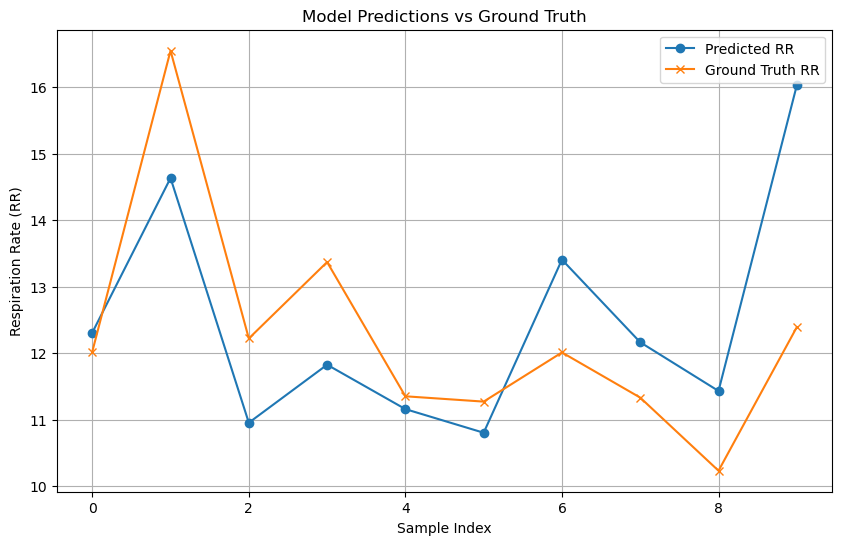